# One insider, every seat: the dossier

Reporting owners get a CIK just like companies do, so a person's whole
footprint is queryable: every issuer they file at, their roles, and
their complete transaction history, normalized across companies.

Subject: Tim Cook, who files at Apple as an officer and at Nike as a
director.

Needs `pandas` and `matplotlib`, and a free API key in
`THREESPREAD_API_KEY` ([signup](https://3spread.com/auth/signup)).

In [1]:
import pandas as pd

from py3spread import Client

client = Client()
COOK = "1214156"

bio = client.insiders.biography(COOK)
print(f"{bio['rpt_owner_name']}: {bio['total_filings']} filings,"
      f" {bio['total_transactions']} transactions on file")
roles = pd.DataFrame(bio["issuers"])
roles["sells_dollars"] = pd.to_numeric(roles["sells_dollars"])
roles["buys_dollars"] = pd.to_numeric(roles["buys_dollars"])
(roles[["issuer_trading_symbol", "issuer_name", "is_officer", "is_director",
        "filing_count", "sells_dollars", "first_transaction_date", "last_transaction_date"]]
 .style.format({"sells_dollars": "${:,.0f}"}).hide(axis="index"))

COOK TIMOTHY D: 39 filings, 99 transactions on file


issuer_trading_symbol,issuer_name,is_officer,is_director,filing_count,sells_dollars,first_transaction_date,last_transaction_date
NKE,"NIKE, Inc.",False,True,14,$0,2021-10-06,2026-04-10
AAPL,Apple Inc.,True,True,25,"$2,216,138,165",2021-08-20,2026-04-02


## Filing history across both issuers

In [2]:
filings = pd.DataFrame(client.insiders.owners(COOK, limit=50)["data"])
filings[["accepted_time", "issuer_trading_symbol", "form_type", "period_of_report"]].head(12)

,accepted_time,issuer_trading_symbol,form_type,period_of_report
0,2026-04-14T00:00:00,NKE,4,2026-04-10
1,2026-04-14T00:00:00,NKE,4,2026-04-10
2,2026-04-03T00:00:00,AAPL,4,2026-04-01
3,2026-04-03T00:00:00,AAPL,4,2026-04-01
4,2025-12-23T00:00:00,NKE,4,2025-12-22
5,2025-12-23T00:00:00,NKE,4,2025-12-22
6,2025-10-03T00:00:00,AAPL,4,2025-10-01
7,2025-10-03T00:00:00,AAPL,4,2025-10-01
8,2025-09-30T00:00:00,AAPL,4,2025-09-28
9,2025-09-30T00:00:00,AAPL,4,2025-09-28


## Transaction timeline

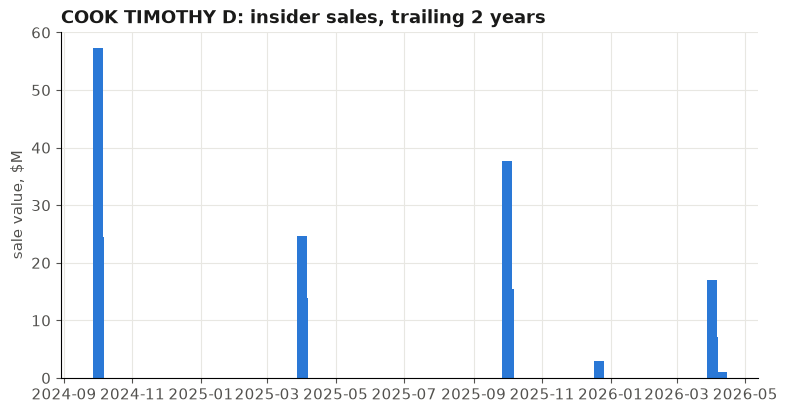

In [3]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (9, 4.5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#e8e7e2",
    "grid.linewidth": 0.8,
    "axes.axisbelow": True,
    "font.size": 11,
    "text.color": "#1a1a19",
    "axes.labelcolor": "#52514e",
    "xtick.color": "#52514e",
    "ytick.color": "#52514e",
})
BLUE = "#2a78d6"
INK = "#52514e"


import datetime as dt

end = dt.date.today()
txns = []
for symbol in roles["issuer_trading_symbol"].unique():
    txns += client.insiders.transactions(
        rpt_owner_cik=COOK, issuer_ticker=symbol, transaction_kind="nonderiv",
        transaction_start=str(end - dt.timedelta(days=729)), transaction_end=str(end),
    )["data"]

df = pd.DataFrame(txns).drop_duplicates(subset=["filing_id", "record_index"])
df = df[df["issuer_trading_symbol"].notna()]
df["transaction_date"] = pd.to_datetime(df["transaction_date"])
df["value"] = pd.to_numeric(df["transaction_total_value"], errors="coerce")
sales = df[df["value"] > 0]

fig, ax = plt.subplots()
ax.bar(sales["transaction_date"], sales["value"] / 1e6, width=9, color=BLUE)
ax.set_title(f"{bio['rpt_owner_name']}: insider sales, trailing 2 years",
             loc="left", fontweight="bold")
ax.set_ylabel("sale value, $M")
plt.show()

The same three calls (biography, owners, transactions) work for any of
the reporting-owner CIKs in the insiders dataset: board interlock
mapping is a loop away.